# Final Project: ECG & Temperature BLE Device

## Battery Voltage Measurement

Verify the accuracy of your battery level measurement (`AIN0`) for 0-3.7 V, as read through the nRF Connect app Bluetooth Battery Level GATT.  Quantitative analysis should include:
  * Linear regression analysis of the input voltage versus the battery level for both the `LOG_INF()` output, the oscilloscope measurement of the PWM duty cycle, and the nRF Connect app.
  * 95% confidence intervals for the slope and intercept of the linear regression.

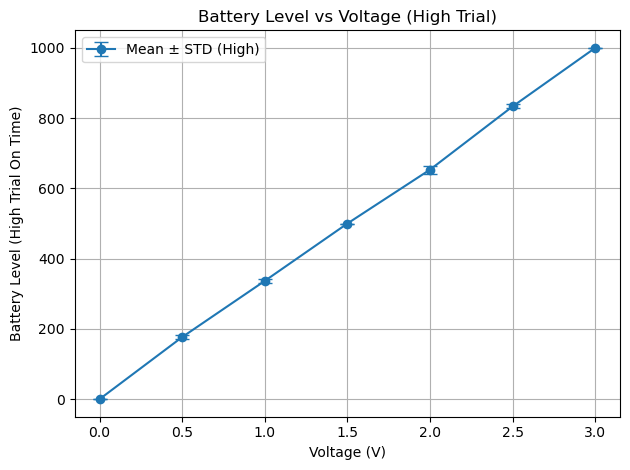

--- Linear Regression Results ---
Slope:     330.7143
Intercept: 3.9286
95% CI for Slope:     [323.9706906  337.45788083]
95% CI for Intercept: [-8.22861755 16.08576041]
R² (vs Ideal): 0.9997


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

file_path = "/Users/arshsingh/Desktop/Spring_2025/BME_554/ecg-temp-ble-project/testing/battery_test.xlsx"
df = pd.read_excel(file_path, header=1, usecols="A:D")

df.columns = ['Voltage', 'Trial 1', 'Trial 2', 'Trial 3']

df['Mean'] = df[['Trial 1', 'Trial 2', 'Trial 3']].mean(axis=1)
df['Std'] = df[['Trial 1', 'Trial 2', 'Trial 3']].std(axis=1)

plt.errorbar(
    df['Voltage'], df['Mean'], yerr=df['Std'],
    fmt='o-', capsize=5, label='Mean ± STD (High)'
)
plt.xlabel("Voltage (V)")
plt.ylabel("Battery Level (High Trial On Time)")
plt.title("Battery Level vs Voltage (High Trial)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

X = sm.add_constant(df['Voltage'])
y = df['Mean']
model = sm.OLS(y, X).fit()

intercept, slope = model.params
conf_int = model.conf_int(alpha=0.05)

ideal = (df['Voltage'] / 3.0) * 830
r_squared = np.corrcoef(df['Mean'], ideal)[0, 1] ** 2

print("--- Linear Regression Results ---")
print(f"Slope:     {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"95% CI for Slope:     {conf_int.loc['Voltage'].values}")
print(f"95% CI for Intercept: {conf_int.loc['const'].values}")
print(f"R² (vs Ideal): {r_squared:.4f}")

## ECG Heart Rate Measurement
Demonstrate that your average heart rate measurement is accurate, as recorded through `LOG_INF()` output, the oscilloscope measurements, and the nRF Connect app, relative to what was set on the function generator.  This should be done for 40, 60, 120, 150, and 180 bpm.  The 25% duty cycle should also be verified. Quantitative analysis should include:
  * Linear regression analysis of the recorded heart rate versus the set heart rate for both the `LOG_INF()` output, oscilloscope measurements, and the nRF Connect app.
  * 95% confidence intervals for the slope and intercept of the linear regression.
  * Verification that the duty cycle of out output is 25% for all heart rates.

### Recorded Heart Rate vs Set Heart Rate

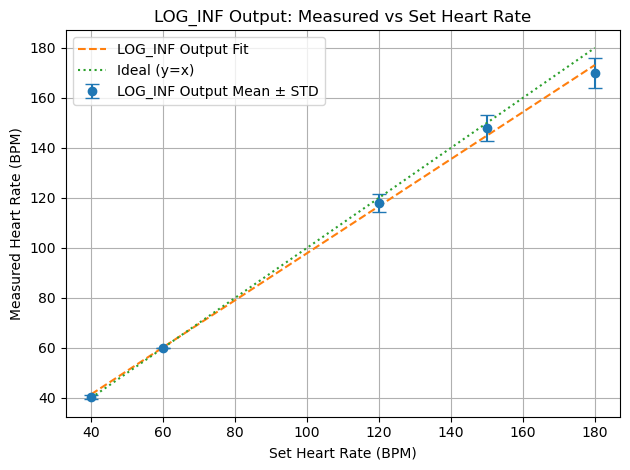


--- LOG_INF Output Linear Regression ---
Slope: 0.9409
Intercept: 3.7857
95% CI for Slope: [0.8676943  1.01401999]
95% CI for Intercept: [-5.14494873 12.71637731]
R² (vs Ideal): 0.9982


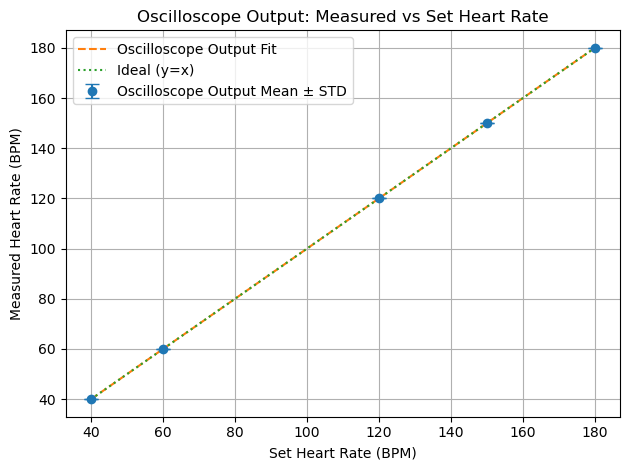


--- Oscilloscope Output Linear Regression ---
Slope: 1.0000
Intercept: 0.0000
95% CI for Slope: [1. 1.]
95% CI for Intercept: [-1.06263460e-13  1.63106879e-13]
R² (vs Ideal): 1.0000


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# === Load and preprocess ===
file_path = "heart_rate_test.xlsx"
df = pd.read_excel(file_path, skiprows=1)

# Rename columns for clarity
df.columns = [
    "Set BPM", "LOG_INF T1", "LOG_INF T2", "LOG_INF T3", "LOG_INF T4", "LOG_INF T5",
    "blank", "Scope T1", "Scope T2", "Scope T3", "Scope T4", "Scope T5"
]

# Drop blank column
df = df.drop(columns=["blank"])

# Compute means and std for both methods
df['LOG_INF Mean'] = df[["LOG_INF T1", "LOG_INF T2", "LOG_INF T3", "LOG_INF T4", "LOG_INF T5"]].mean(axis=1)
df['LOG_INF Std']  = df[["LOG_INF T1", "LOG_INF T2", "LOG_INF T3", "LOG_INF T4", "LOG_INF T5"]].std(axis=1)

df['Scope Mean']   = df[["Scope T1", "Scope T2", "Scope T3", "Scope T4", "Scope T5"]].mean(axis=1)
df['Scope Std']    = df[["Scope T1", "Scope T2", "Scope T3", "Scope T4", "Scope T5"]].std(axis=1)

# === Regression Function ===
def run_regression(x, y, y_std, label):
    plt.errorbar(x, y, yerr=y_std, fmt='o', capsize=5, label=f'{label} Mean ± STD')
    
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    intercept, slope = model.params
    conf_int = model.conf_int(alpha=0.05)

    # Ideal (perfect fit = identity)
    ideal = x
    r_squared = np.corrcoef(y, ideal)[0, 1] ** 2

    plt.plot(x, model.predict(X), '--', label=f'{label} Fit')
    plt.plot(x, ideal, ':', label='Ideal (y=x)')

    plt.xlabel("Set Heart Rate (BPM)")
    plt.ylabel("Measured Heart Rate (BPM)")
    plt.title(f"{label}: Measured vs Set Heart Rate")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"\n--- {label} Linear Regression ---")
    print(f"Slope: {slope:.4f}")
    print(f"Intercept: {intercept:.4f}")
    print(f"95% CI for Slope: {conf_int.loc['Set BPM'].values}")
    print(f"95% CI for Intercept: {conf_int.loc['const'].values}")
    print(f"R² (vs Ideal): {r_squared:.4f}")

# === Run both regressions ===
run_regression(df['Set BPM'], df['LOG_INF Mean'], df['LOG_INF Std'], label="LOG_INF Output")
run_regression(df['Set BPM'], df['Scope Mean'], df['Scope Std'], label="Oscilloscope Output")


### 25% Duty Cycle

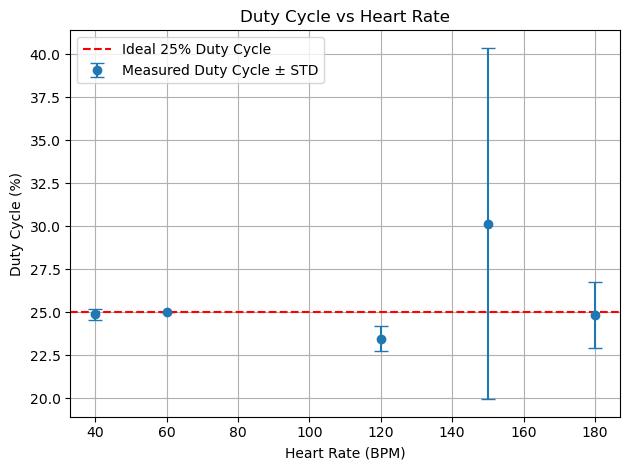

--- Duty Cycle Verification ---
40 BPM: Mean = 24.89% ± 0.32%
60 BPM: Mean = 25.00% ± 0.00%
120 BPM: Mean = 23.47% ± 0.74%
150 BPM: Mean = 30.17% ± 10.21%
180 BPM: Mean = 24.83% ± 1.92%


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Excel sheet
file_path = "25_percent_duty_cycle_test.xlsx"  # Update if needed
df = pd.read_excel(file_path, header=1)


# Rename columns for clarity
df.columns = [
    "Heart Rate", "High T1", "High T2", "High T3", "High T4", "High T5",
    "blank", "Low T1", "Low T2", "Low T3", "Low T4", "Low T5"
]
df = df.drop(columns=["blank"])

# Convert to numeric
df = df.apply(pd.to_numeric, errors="coerce")

# Compute duty cycle for each trial
high_cols = [col for col in df.columns if "High" in col]
low_cols  = [col for col in df.columns if "Low" in col]

duty_cycles = pd.DataFrame()
for h_col, l_col in zip(high_cols, low_cols):
    duty_cycles[h_col.replace("High", "Duty")] = (
        df[h_col] / (df[h_col] + df[l_col]) * 100
    )

# Compute mean and std of duty cycle across trials
df["Duty Mean"] = duty_cycles.mean(axis=1)
df["Duty Std"]  = duty_cycles.std(axis=1)

# Plotting
plt.errorbar(
    df["Heart Rate"], df["Duty Mean"], yerr=df["Duty Std"],
    fmt="o", capsize=5, label="Measured Duty Cycle ± STD"
)
plt.axhline(25, color="r", linestyle="--", label="Ideal 25% Duty Cycle")
plt.xlabel("Heart Rate (BPM)")
plt.ylabel("Duty Cycle (%)")
plt.title("Duty Cycle vs Heart Rate")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Print results
print("--- Duty Cycle Verification ---")
for idx, row in df.iterrows():
    print(f"{int(row['Heart Rate'])} BPM: Mean = {row['Duty Mean']:.2f}% ± {row['Duty Std']:.2f}%")


## Temperature Sensor Measurment

Demonstrate that your temperature sensor can have a room temperature measurement read through `LOG_INF()` output and the nRF Connect app.  Do this in 3 locations with different temperatures.  You do not need to verify accuracy, just a reasonable measurements with agreement.

In [1]:
# Temperature Sensor Verification Here

#### Room Temperature Measurements

LOG_INF output
1) Lab Temperature - 24 degrees Celsius
2) Apartment Temperature - 23.5 degrees Celsius
3) Fitzpatrick Temperature - 24.5 degrees Celsius

nRF Connect App
1) Lab Temperature - degrees Celsius
2) Apartment Temperature - degrees Celsius
3) Fitzpatrick Temperature - degrees Celsius